# Applied AI & ML Essentials — Capstone Project

# Part 2 — Supervised Machine Learning Model: Build, Train, and Evaluate

## Dataset Information

- **Dataset Name:** Adult Income (Census Income) Dataset
- **Source:** UCI Machine Learning Repository
- **Dataset URL:** https://archive.ics.uci.edu/dataset/2/adult
- **Input Dataset:** cleaned_data.csv (Generated in Part 1)
- **Number of Records:** 48,842 (Before Cleaning)
- **Number of Features:** 14
- **Task Type:** Regression + Binary Classification
- **Regression Target:** hours_per_week
- **Classification Target:** income (<=50K / >50K)

### Original Dataset Author

- **Barry Becker**
- **Silicon Graphics**

### Donor

- **Ronny Kohavi**
- **Consultant, Stanford University**
- **Email:** ronnyk@live.com

---

## Project Objective

The objective of this part is to build, train, and evaluate supervised machine learning models using the cleaned dataset generated in Part 1 (`cleaned_data.csv`). The project includes feature engineering, categorical encoding, leak-free data preprocessing, train-test splitting, feature scaling, regression and classification model development, class imbalance handling, model evaluation, ROC-AUC analysis, decision threshold optimization, regularization experiments, and bootstrap confidence interval analysis. The implementation follows industry-standard machine learning practices and fulfills all official requirements of the **Applied AI & ML Essentials Capstone Project**.

In [45]:
# ─── Step 1: Install Required Libraries ──────────────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

# ─── Import All Libraries ─────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge

# Classification Model
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics — Regression
from sklearn.metrics import mean_squared_error, r2_score

# Evaluation Metrics — Classification
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Class Imbalance
from imblearn.over_sampling import SMOTE

# ─── Global Settings ──────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"    : 120,
    "figure.figsize": (10, 6)
})

# ─── Verify ───────────────────────────────────────────────────────────────────
print("✅ All libraries imported successfully")
print(f"   numpy   : {np.__version__}")
print(f"   pandas  : {pd.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")
print(f"   seaborn : {sns.__version__}")

✅ All libraries imported successfully
   numpy   : 2.0.2
   pandas  : 2.2.2
   sklearn : 1.6.1
   seaborn : 0.13.2


Load Data — load cleaned_data.csv and inspect
Task 1 — load dataset

In [46]:
# ─── Step 2: Load cleaned_data.csv ───────────────────────────────────────────

# Load cleaned dataset from Part 1
df = pd.read_csv("cleaned_data.csv")

# ─── Shape ────────────────────────────────────────────────────────────────────
print("── Shape:")
print(f"   {df.shape[0]:,} rows × {df.shape[1]} columns")

# ─── First 5 rows ─────────────────────────────────────────────────────────────
print("\n── First 5 rows:")
print(df.head())

# ─── Column dtypes ────────────────────────────────────────────────────────────
print("\n── Column dtypes:")
print(df.dtypes)

# ─── Null check ───────────────────────────────────────────────────────────────
print("\n── Null check (must all be 0):")
print(df.isnull().sum())

# ─── Basic statistics ─────────────────────────────────────────────────────────
print("\n── Basic statistics:")
print(df.describe().round(2))

── Shape:
   32,537 rows × 15 columns

── First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country  income  
0          2174             0              40  United-S

Define Targets — X, y_reg=hours_per_week, y_clf=income           
Task 1 — define all targets with README definitions

In [47]:
# ─── Step 3: Define X, y_reg, y_clf ──────────────────────────────────────────

# ── Regression target — continuous numeric column ─────────────────────────────
y_reg = df['hours_per_week'].copy()

# ── Classification target — existing binary column ────────────────────────────
y_clf = df['income'].copy()

# ── Feature matrix — drop both target columns ─────────────────────────────────
X = df.drop(columns=['hours_per_week', 'income'])

# ─── Verify ───────────────────────────────────────────────────────────────────
print("── Feature Matrix X:")
print(f"   Shape   : {X.shape}")
print(f"   Columns : {X.columns.tolist()}")

print(f"\n── Regression Target y_reg (hours_per_week):")
print(f"   Shape : {y_reg.shape}")
print(f"   Min   : {y_reg.min()}")
print(f"   Max   : {y_reg.max()}")
print(f"   Mean  : {y_reg.mean():.2f}")

print(f"\n── Classification Target y_clf (income):")
print(f"   Shape : {y_clf.shape}")
print(f"\n   Value counts:")
print(y_clf.value_counts())
print(f"\n   Class balance (%):")
print((y_clf.value_counts(normalize=True) * 100).round(2))

── Feature Matrix X:
   Shape   : (32537, 13)
   Columns : ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'native_country']

── Regression Target y_reg (hours_per_week):
   Shape : (32537,)
   Min   : 1
   Max   : 99
   Mean  : 40.44

── Classification Target y_clf (income):
   Shape : (32537,)

   Value counts:
income
0    24698
1     7839
Name: count, dtype: int64

   Class balance (%):
income
0    75.91
1    24.09
Name: proportion, dtype: float64


Encode Categories — label encoding + one-hot encoding + drop first dummy

Task 2 — full encoding with README explanation

In [48]:
## Step 4 — Encode Categorical Features
# ─── Check all column types ───────────────────────────────────────────────────

print("── All columns and dtypes:")
print(X.dtypes)

print(f"\n── Categorical columns:")
print(X.select_dtypes(include=['category','object']).columns.tolist())

print(f"\n── Numeric columns:")
print(X.select_dtypes(include='number').columns.tolist())

── All columns and dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
native_country    object
dtype: object

── Categorical columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

── Numeric columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss']


In [49]:
# ─── Drop raw education column ────────────────────────────────────────────────


if 'education' in X.columns:
    X = X.drop(columns=['education'])
    print("✅ Dropped 'education' — keeping 'education_num'")
else:
    print("── 'education' not found — already removed")

print(f"── Shape after drop: {X.shape}")

✅ Dropped 'education' — keeping 'education_num'
── Shape after drop: (32537, 12)


In [50]:
# ─── One-Hot Encode all remaining categorical columns ─────────────────────────

# Auto-detect category and object columns
cols_to_encode = X.select_dtypes(
    include=['category', 'object']
).columns.tolist()

print(f"── Columns to encode : {cols_to_encode}")
print(f"── Shape BEFORE      : {X.shape}")

# Apply One-Hot Encoding
X = pd.get_dummies(
    X,
    columns    = cols_to_encode,
    drop_first = True,
    dtype      = int
)

print(f"── Shape AFTER       : {X.shape}")
print(f"── Nulls remaining   : {X.isnull().sum().sum()}")
print(f"── All numeric       : {all(X.dtypes != 'object')}")

── Columns to encode : ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
── Shape BEFORE      : (32537, 12)
── Shape AFTER       : (32537, 81)
── Nulls remaining   : 0
── All numeric       : True


In [51]:
# ─── Final verification ───────────────────────────────────────────────────────

print("── dtype summary:")
print(X.dtypes.value_counts())

print(f"\n── Shape          : {X.shape}")
print(f"── Total nulls    : {X.isnull().sum().sum()}")

print(f"\n── Sample (first 3 rows):")
print(X.head(3))

── dtype summary:
int64    81
Name: count, dtype: int64

── Shape          : (32537, 81)
── Total nulls    : 0

── Sample (first 3 rows):
   age  fnlwgt  education_num  capital_gain  capital_loss  \
0   39   77516             13          2174             0   
1   50   83311             13             0             0   
2   38  215646              9             0             0   

   workclass_Local-gov  workclass_Never-worked  workclass_Private  \
0                    0                       0                  0   
1                    0                       0                  0   
2                    0                       0                  1   

   workclass_Self-emp-inc  workclass_Self-emp-not-inc  ...  \
0                       0                           0  ...   
1                       0                           1  ...   
2                       0                           0  ...   

   native_country_Portugal  native_country_Puerto-Rico  \
0                        0       

Train-Test Split + Scaling — split then fit scaler on train only

Task 3 — leak-free split and scaling with README


In [52]:
# ─── Step 5: Train-Test Split ─────────────────────────────────────────────────

# Split for regression
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg,
    test_size    = 0.2,
    random_state = 42
)

# Split for classification (same X split)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf,
    test_size    = 0.2,
    random_state = 42
)

print("── Train-Test Split Results:")
print(f"   X_train shape : {X_train.shape}")
print(f"   X_test shape  : {X_test.shape}")
print(f"\n── Regression:")
print(f"   y_reg_train   : {y_reg_train.shape}")
print(f"   y_reg_test    : {y_reg_test.shape}")
print(f"\n── Classification:")
print(f"   y_clf_train   : {y_clf_train.shape}")
print(f"   y_clf_test    : {y_clf_test.shape}")

── Train-Test Split Results:
   X_train shape : (26029, 81)
   X_test shape  : (6508, 81)

── Regression:
   y_reg_train   : (26029,)
   y_reg_test    : (6508,)

── Classification:
   y_clf_train   : (26029,)
   y_clf_test    : (6508,)


In [53]:
# ─── Leak-Free Scaling ────────────────────────────────────────────────────────
# IMPORTANT: Fit scaler ONLY on training data
# NEVER fit on full dataset — causes data leakage

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train)

# Transform both train and test separately
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("── Scaling Complete:")
print(f"   X_train_scaled shape : {X_train_scaled.shape}")
print(f"   X_test_scaled shape  : {X_test_scaled.shape}")

print(f"\n── Train mean (should be ~0):")
print(f"   {X_train_scaled.mean():.6f}")

print(f"\n── Train std (should be ~1):")
print(f"   {X_train_scaled.std():.6f}")

print(f"\n── Test mean (not exactly 0 — expected):")
print(f"   {X_test_scaled.mean():.6f}")

── Scaling Complete:
   X_train_scaled shape : (26029, 81)
   X_test_scaled shape  : (6508, 81)

── Train mean (should be ~0):
   0.000000

── Train std (should be ~1):
   1.000000

── Test mean (not exactly 0 — expected):
   -0.002326


In [54]:
# ─── Verify class balance in train and test ───────────────────────────────────

print("── Class balance in y_clf_train:")
print(y_clf_train.value_counts())
print((y_clf_train.value_counts(normalize=True)*100).round(2))

print("\n── Class balance in y_clf_test:")
print(y_clf_test.value_counts())
print((y_clf_test.value_counts(normalize=True)*100).round(2))

── Class balance in y_clf_train:
income
0    19793
1     6236
Name: count, dtype: int64
income
0    76.04
1    23.96
Name: proportion, dtype: float64

── Class balance in y_clf_test:
income
0    4905
1    1603
Name: count, dtype: int64
income
0    75.37
1    24.63
Name: proportion, dtype: float64


Linear Regression — Train, predict, calculate MSE & R², print coefficients, identify Top 3 features, save regression plot
          
          Task 4 — Complete Linear Regression with README

In [55]:
# ─── Step 6: Linear Regression ───────────────────────────────────────────────

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)

# Predict on test set
y_pred_reg = lin_reg.predict(X_test_scaled)

print("✅ Linear Regression trained successfully")
print(f"── Training samples : {X_train_scaled.shape[0]:,}")
print(f"── Test samples     : {X_test_scaled.shape[0]:,}")

✅ Linear Regression trained successfully
── Training samples : 26,029
── Test samples     : 6,508


In [56]:
# ─── Evaluate Regression ──────────────────────────────────────────────────────

mse_lin = mean_squared_error(y_reg_test, y_pred_reg)
r2_lin  = r2_score(y_reg_test, y_pred_reg)

print("── Linear Regression Results:")
print(f"   MSE : {mse_lin:.4f}")
print(f"   R²  : {r2_lin:.4f}")

── Linear Regression Results:
   MSE : 125.8712
   R²  : 0.1771


In [57]:
# ─── Coefficients with Feature Names ─────────────────────────────────────────

feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("── All Coefficients (sorted by absolute value):")
print(coef_df.to_string(index=False))

# Top 3 features
top3 = coef_df.head(3)
print("\n── Top 3 Features by Absolute Coefficient:")
print(top3.to_string(index=False))

── All Coefficients (sorted by absolute value):
                                  Feature  Coefficient
                   relationship_Own-child    -1.954905
                            education_num     1.552244
             marital_status_Never-married    -1.449973
                                 sex_Male     1.361667
                                      age    -1.298679
               occupation_Farming-fishing     1.169628
               occupation_Exec-managerial     1.093190
              occupation_Transport-moving     1.029316
                   workclass_Self-emp-inc     0.931057
                   marital_status_Widowed    -0.920139
               relationship_Not-in-family     0.769390
                        relationship_Wife    -0.745299
                 occupation_Other-service    -0.619648
                  occupation_Craft-repair     0.582592
        marital_status_Married-civ-spouse     0.518588
             occupation_Machine-op-inspct     0.512278
                 

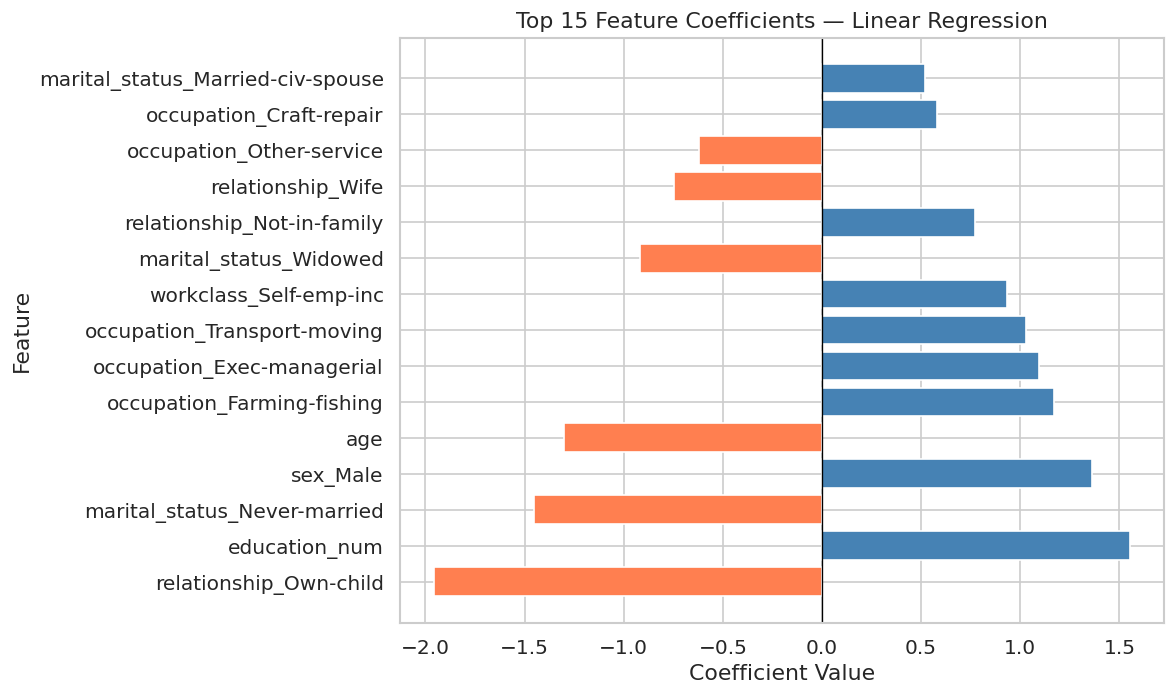

✅ Saved → linear_regression_coefficients.png


In [58]:
# ─── Plot Top 15 Coefficients ─────────────────────────────────────────────────

top15 = coef_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top15['Feature'],
    top15['Coefficient'],
    color = ['steelblue' if c > 0 else 'coral'
             for c in top15['Coefficient']]
)
plt.title("Top 15 Feature Coefficients — Linear Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig("linear_regression_coefficients.png")
plt.show()
print("✅ Saved → linear_regression_coefficients.png")

Ridge Regression — Train Ridge model, compare with OLS using MSE & R², explain Alpha parameter
     
     Task 4 — Ridge comparison with README

In [59]:
# ─── Step 7: Ridge Regression ────────────────────────────────────────────────

# Train Ridge Regression with alpha=1.0
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled, y_reg_train)

# Predict on test set
y_pred_ridge = ridge_reg.predict(X_test_scaled)

print("✅ Ridge Regression trained successfully")
print(f"   alpha : 1.0")

✅ Ridge Regression trained successfully
   alpha : 1.0


In [60]:
# ─── Evaluate Ridge ───────────────────────────────────────────────────────────

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge  = r2_score(y_reg_test, y_pred_ridge)

print("── Ridge Regression Results:")
print(f"   MSE : {mse_ridge:.4f}")
print(f"   R²  : {r2_ridge:.4f}")

── Ridge Regression Results:
   MSE : 125.8711
   R²  : 0.1771


In [61]:
# ─── Ridge vs OLS Comparison Table ───────────────────────────────────────────

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Ridge Regression (alpha=1.0)'],
    'MSE'  : [round(mse_lin, 4), round(mse_ridge, 4)],
    'R²'   : [round(r2_lin, 4),  round(r2_ridge, 4)]
})

print("── Ridge vs OLS Comparison:")
print(comparison_df.to_string(index=False))

# Which model is better
if mse_ridge < mse_lin:
    print("\n── Ridge has LOWER MSE → better performance")
else:
    print("\n── OLS has LOWER MSE → better performance")

── Ridge vs OLS Comparison:
                       Model      MSE     R²
     Linear Regression (OLS) 125.8712 0.1771
Ridge Regression (alpha=1.0) 125.8711 0.1771

── Ridge has LOWER MSE → better performance


In [62]:
# ─── Compare Coefficients Ridge vs OLS ───────────────────────────────────────

coef_compare = pd.DataFrame({
    'Feature'        : X.columns.tolist(),
    'OLS Coefficient': lin_reg.coef_,
    'Ridge Coefficient': ridge_reg.coef_
}).sort_values('OLS Coefficient', key=abs, ascending=False)

print("── Top 10 Coefficient Comparison (Ridge vs OLS):")
print(coef_compare.head(10).to_string(index=False))

── Top 10 Coefficient Comparison (Ridge vs OLS):
                     Feature  OLS Coefficient  Ridge Coefficient
      relationship_Own-child        -1.954905          -1.954824
               education_num         1.552244           1.552160
marital_status_Never-married        -1.449973          -1.449812
                    sex_Male         1.361667           1.361647
                         age        -1.298679          -1.298538
  occupation_Farming-fishing         1.169628           1.169525
  occupation_Exec-managerial         1.093190           1.093073
 occupation_Transport-moving         1.029316           1.029207
      workclass_Self-emp-inc         0.931057           0.931011
      marital_status_Widowed        -0.920139          -0.920106


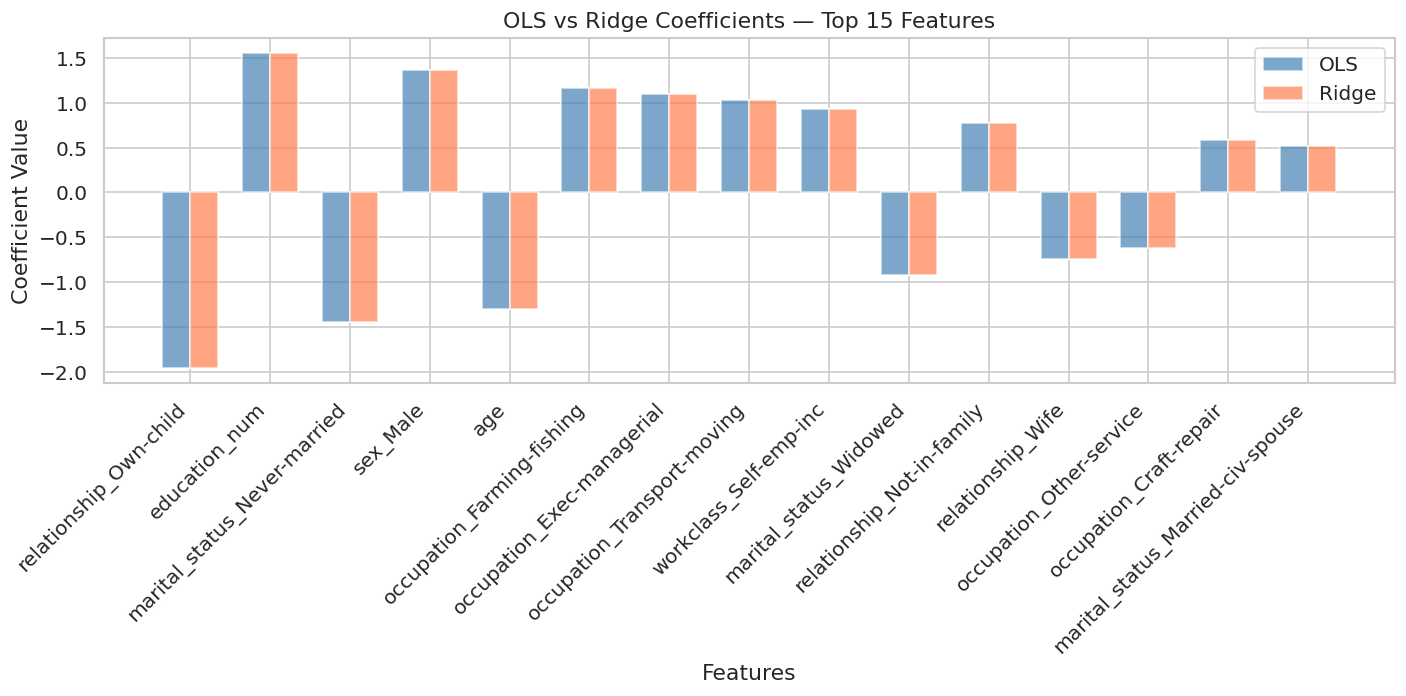

✅ Saved → ridge_vs_ols_coefficients.png


In [63]:
# ─── Plot Ridge vs OLS Coefficients ──────────────────────────────────────────

top15_features = coef_compare.head(15)

x      = range(len(top15_features))
width  = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x,
        top15_features['OLS Coefficient'],
        width,
        label = 'OLS',
        color = 'steelblue',
        alpha = 0.7)
plt.bar([i + width for i in x],
        top15_features['Ridge Coefficient'],
        width,
        label = 'Ridge',
        color = 'coral',
        alpha = 0.7)

plt.title("OLS vs Ridge Coefficients — Top 15 Features")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks([i + width/2 for i in x],
           top15_features['Feature'],
           rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("ridge_vs_ols_coefficients.png")
plt.show()
print("✅ Saved → ridge_vs_ols_coefficients.png")

Class Imbalance Handling — Check class distribution, apply class_weight='balanced' (or SMOTE if required), show before/after comparison

Task 5 — Class imbalance handling with README

In [64]:
# ─── Step 8: Check Class Imbalance ───────────────────────────────────────────

print("── Class Distribution BEFORE Balancing:")
print(y_clf_train.value_counts())
print()
print((y_clf_train.value_counts(normalize=True)*100).round(2))

# Check if minority class is below 35%
minority_pct = y_clf_train.value_counts(normalize=True).min() * 100

print(f"\n── Minority class percentage : {minority_pct:.2f}%")

if minority_pct < 35:
    print("── Imbalance detected → applying class_weight='balanced'")
else:
    print("── Classes are balanced → no action needed")

── Class Distribution BEFORE Balancing:
income
0    19793
1     6236
Name: count, dtype: int64

income
0    76.04
1    23.96
Name: proportion, dtype: float64

── Minority class percentage : 23.96%
── Imbalance detected → applying class_weight='balanced'


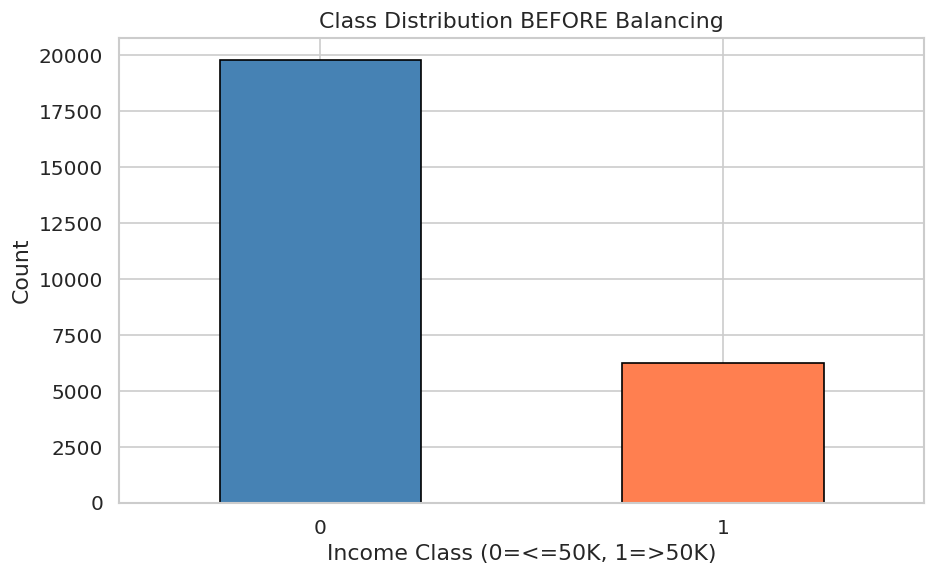

✅ Saved → class_distribution_before.png


In [65]:
# ─── Plot class distribution BEFORE ──────────────────────────────────────────

plt.figure(figsize=(8, 5))
y_clf_train.value_counts().plot.bar(
    color     = ['steelblue', 'coral'],
    edgecolor = 'black'
)
plt.title("Class Distribution BEFORE Balancing")
plt.xlabel("Income Class (0=<=50K, 1=>50K)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution_before.png")
plt.show()
print("✅ Saved → class_distribution_before.png")

In [66]:
# ─── Apply class_weight='balanced' ───────────────────────────────────────────

# Show effective class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = classes,
    y            = y_clf_train
)

weight_dict = dict(zip(classes, weights))

print("── Effective class weights (balanced):")
for cls, wt in weight_dict.items():
    label = '<=50K' if cls == 0 else '>50K'
    print(f"   Class {cls} ({label}) : {wt:.4f}")

print("\n── Method chosen : class_weight='balanced'")
print("── Reason        : Simple, effective, no data")
print("                   modification needed.")
print("                   Minority class gets higher")
print("                   weight during training.")

── Effective class weights (balanced):
   Class 0 (<=50K) : 0.6575
   Class 1 (>50K) : 2.0870

── Method chosen : class_weight='balanced'
── Reason        : Simple, effective, no data
                   modification needed.
                   Minority class gets higher
                   weight during training.


In [67]:
# ─── Show effective sample counts after weighting ────────────────────────────

count_0 = (y_clf_train == 0).sum()
count_1 = (y_clf_train == 1).sum()

effective_0 = count_0 * weight_dict[0]
effective_1 = count_1 * weight_dict[1]

print("── Before vs After Effective Counts:")
print(f"\n   {'Class':<10} {'Actual Count':>14} {'Effective Weight':>18}")
print("   " + "-" * 45)
print(f"   {'0 (<=50K)':<10} {count_0:>14,} {effective_0:>18.2f}")
print(f"   {'1 (>50K)':<10}  {count_1:>14,} {effective_1:>18.2f}")

print(f"\n── Effective counts are now balanced ✅")

── Before vs After Effective Counts:

   Class        Actual Count   Effective Weight
   ---------------------------------------------
   0 (<=50K)          19,793           13014.50
   1 (>50K)             6,236           13014.50

── Effective counts are now balanced ✅


Logistic Regression — Train model (max_iter=1000)

Task 5 — Train classifier

In [68]:
# ─── Step 9: Logistic Regression ─────────────────────────────────────────────

# Train Logistic Regression with balanced class weight
log_reg = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    C            = 1.0,
    random_state = 42
)

log_reg.fit(X_train_scaled, y_clf_train)

print("✅ Logistic Regression trained successfully")
print(f"   class_weight : balanced")
print(f"   max_iter     : 1000")
print(f"   C            : 1.0")
print(f"   random_state : 42")

✅ Logistic Regression trained successfully
   class_weight : balanced
   max_iter     : 1000
   C            : 1.0
   random_state : 42


In [69]:
# ─── Predict class labels ─────────────────────────────────────────────────────
y_pred_clf = log_reg.predict(X_test_scaled)

# ─── Predict probabilities ────────────────────────────────────────────────────
y_proba_clf = log_reg.predict_proba(X_test_scaled)[:, 1]

print("── Predictions complete")
print(f"\n── Predicted labels sample:")
print(y_pred_clf[:10])

print(f"\n── Predicted probabilities sample:")
print(y_proba_clf[:10].round(4))

print(f"\n── Prediction counts:")
unique, counts = np.unique(y_pred_clf, return_counts=True)
for u, c in zip(unique, counts):
    label = '<=50K' if u == 0 else '>50K'
    print(f"   Class {u} ({label}) : {c:,}")

── Predictions complete

── Predicted labels sample:
[1 1 1 0 1 0 0 0 1 1]

── Predicted probabilities sample:
[0.5607 0.5393 0.505  0.2426 0.6385 0.0435 0.0123 0.0032 0.6704 0.9226]

── Prediction counts:
   Class 0 (<=50K) : 4,093
   Class 1 (>50K) : 2,415


Classification Evaluation — Confusion Matrix, Classification Report, Accuracy, Precision, Recall & F1-score

Task 5 — Complete evaluation with README

In [70]:
# ─── Step 10: Classification Evaluation ──────────────────────────────────────

# Compute confusion matrix
cm = confusion_matrix(y_clf_test, y_pred_clf)

print("── Confusion Matrix:")
print(cm)

print(f"\n── Breakdown:")
print(f"   True Negative  (TN) : {cm[0][0]:,}")
print(f"   False Positive (FP) : {cm[0][1]:,}")
print(f"   False Negative (FN) : {cm[1][0]:,}")
print(f"   True Positive  (TP) : {cm[1][1]:,}")

── Confusion Matrix:
[[3858 1047]
 [ 235 1368]]

── Breakdown:
   True Negative  (TN) : 3,858
   False Positive (FP) : 1,047
   False Negative (FN) : 235
   True Positive  (TP) : 1,368


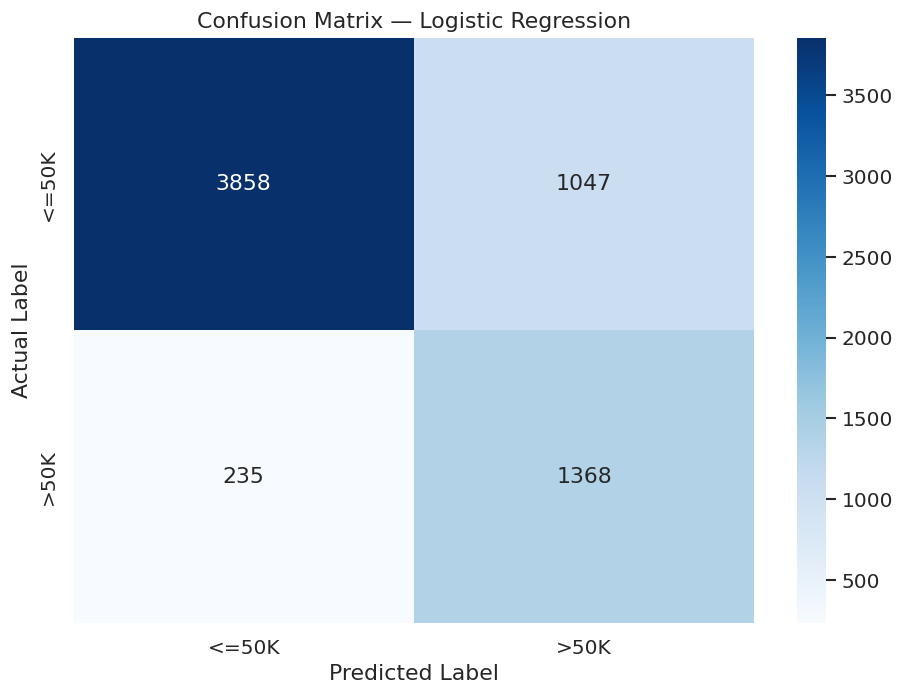

✅ Saved → confusion_matrix.png


In [71]:
# ─── Plot Confusion Matrix ────────────────────────────────────────────────────

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= ['<=50K', '>50K'],
    yticklabels= ['<=50K', '>50K']
)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("✅ Saved → confusion_matrix.png")

In [72]:
# ─── Classification Report ────────────────────────────────────────────────────

print("── Classification Report:")
print(classification_report(
    y_clf_test,
    y_pred_clf,
    target_names = ['<=50K', '>50K']
))

── Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      4905
        >50K       0.57      0.85      0.68      1603

    accuracy                           0.80      6508
   macro avg       0.75      0.82      0.77      6508
weighted avg       0.85      0.80      0.81      6508



In [73]:
# ─── Individual Metrics ───────────────────────────────────────────────────────

accuracy  = (y_pred_clf == y_clf_test).mean()
precision = precision_score(y_clf_test, y_pred_clf)
recall    = recall_score(y_clf_test, y_pred_clf)
f1        = f1_score(y_clf_test, y_pred_clf)

print("── Individual Metrics:")
print(f"   Accuracy  : {accuracy:.4f}")
print(f"   Precision : {precision:.4f}")
print(f"   Recall    : {recall:.4f}")
print(f"   F1 Score  : {f1:.4f}")

── Individual Metrics:
   Accuracy  : 0.8030
   Precision : 0.5665
   Recall    : 0.8534
   F1 Score  : 0.6809


ROC Curve & AUC — Plot ROC Curve, calculate AUC, annotate AUC, save PNG, interpret AUC in README

Task 5 — ROC Curve & AUC

In [74]:
# ─── Step 11: ROC Curve and AUC ──────────────────────────────────────────────

# Predicted probabilities
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_clf_test, y_proba)

# Compute AUC
auc_score = roc_auc_score(y_clf_test, y_proba)

print(f"── AUC Score : {auc_score:.4f}")

── AUC Score : 0.9006


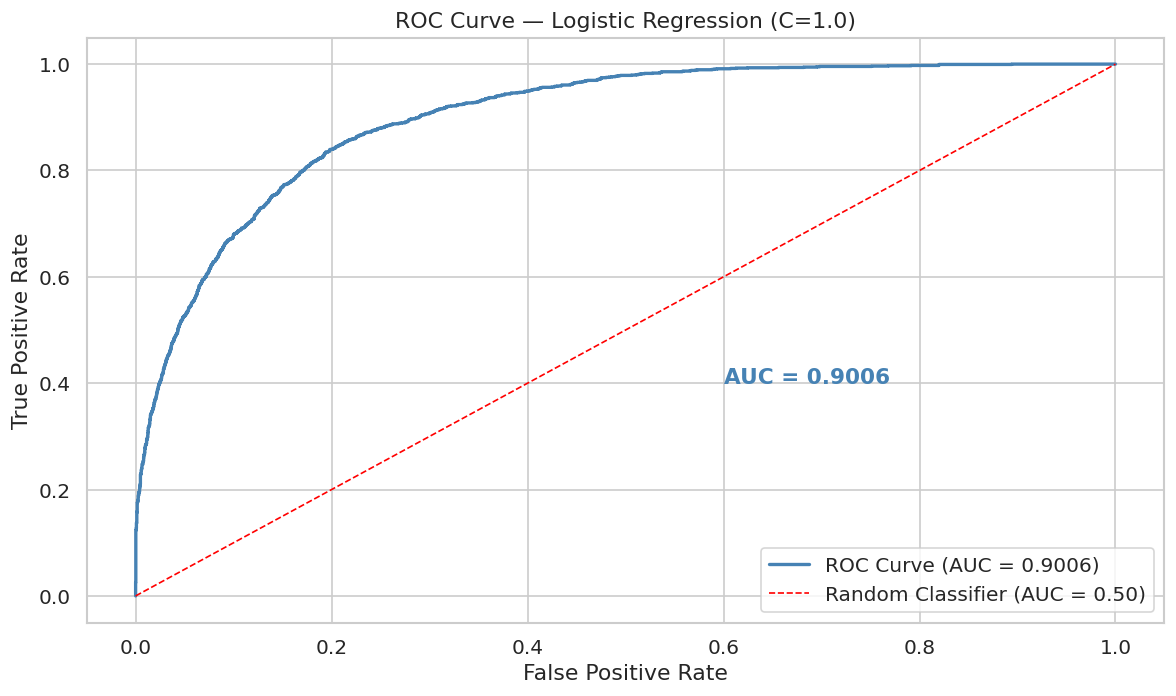

✅ Saved → roc_curve.png


In [75]:
# ─── Plot ROC Curve ───────────────────────────────────────────────────────────

plt.figure(figsize=(10, 6))

# ROC curve
plt.plot(
    fpr, tpr,
    color     = 'steelblue',
    linewidth = 2,
    label     = f'ROC Curve (AUC = {auc_score:.4f})'
)

# Random classifier baseline
plt.plot(
    [0, 1], [0, 1],
    color     = 'red',
    linewidth = 1,
    linestyle = '--',
    label     = 'Random Classifier (AUC = 0.50)'
)

# Annotate AUC on plot
plt.annotate(
    f'AUC = {auc_score:.4f}',
    xy         = (0.6, 0.4),
    fontsize   = 13,
    color      = 'steelblue',
    fontweight = 'bold'
)

plt.title("ROC Curve — Logistic Regression (C=1.0)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

print("✅ Saved → roc_curve.png")

Decision Threshold Analysis — Evaluate thresholds (0.30–0.70), compute Precision, Recall & F1-score, identify best threshold, explain Precision–Recall trade-off

Task 5(b) — Threshold sensitivity with README

In [76]:
# ─── Step 12: Decision Threshold Analysis ────────────────────────────────────

# Predicted probabilities
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate each threshold
results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:

    # Convert probabilities to predictions
    y_pred_t = (y_proba >= threshold).astype(int)

    # Compute metrics
    p  = precision_score(y_clf_test, y_pred_t, zero_division=0)
    r  = recall_score(y_clf_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_clf_test, y_pred_t, zero_division=0)

    results.append({
        "Threshold" : threshold,
        "Precision" : round(p, 4),
        "Recall"    : round(r, 4),
        "F1"        : round(f1, 4)
    })

# Print table
results_df = pd.DataFrame(results)

print("── Threshold Sensitivity Analysis:")
print()
print(results_df.to_string(index=False))

# Best threshold
best_row = results_df.loc[results_df["F1"].idxmax()]
print(f"\n── Best Threshold : {best_row['Threshold']}")
print(f"── Best F1 Score  : {best_row['F1']:.4f}")

── Threshold Sensitivity Analysis:

 Threshold  Precision  Recall     F1
       0.3     0.4667  0.9276 0.6210
       0.4     0.5107  0.8958 0.6505
       0.5     0.5665  0.8534 0.6809
       0.6     0.6258  0.7698 0.6903
       0.7     0.6885  0.6744 0.6814

── Best Threshold : 0.6
── Best F1 Score  : 0.6903


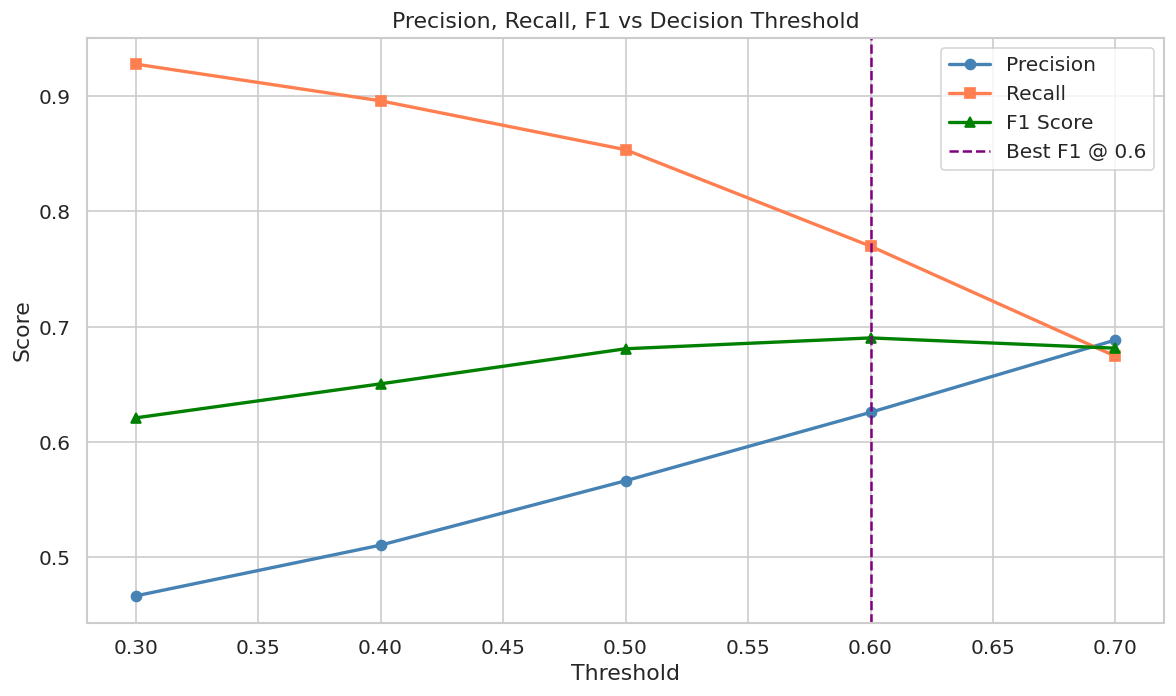

✅ Saved → threshold_analysis.png


In [77]:
# ─── Plot Threshold vs Metrics ────────────────────────────────────────────────

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker    = 'o',
    color     = 'steelblue',
    linewidth = 2,
    label     = "Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker    = 's',
    color     = 'coral',
    linewidth = 2,
    label     = "Recall"
)

plt.plot(
    results_df["Threshold"],
    results_df["F1"],
    marker    = '^',
    color     = 'green',
    linewidth = 2,
    label     = "F1 Score"
)

# Mark best threshold
plt.axvline(
    x         = best_row["Threshold"],
    color     = 'purple',
    linestyle = '--',
    linewidth = 1.5,
    label     = f"Best F1 @ {best_row['Threshold']}"
)

plt.title("Precision, Recall, F1 vs Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_analysis.png")
plt.show()

print("✅ Saved → threshold_analysis.png")

Regularization Experiment — Compare Logistic Regression (C=1.0) vs (C=0.01), explain effect of C

Task 6 — Regularization with README

In [78]:
# ─── Step 13: Regularization Experiment ──────────────────────────────────────

# Train second Logistic Regression with C=0.01
log_reg_strong = LogisticRegression(
    C            = 0.01,
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42
)

log_reg_strong.fit(X_train_scaled, y_clf_train)

print("✅ Logistic Regression C=0.01 trained")
print(f"   C            : 0.01 (strong regularization)")
print(f"   class_weight : balanced")
print(f"   max_iter     : 1000")

✅ Logistic Regression C=0.01 trained
   C            : 0.01 (strong regularization)
   class_weight : balanced
   max_iter     : 1000


In [79]:
# ─── Predict with C=0.01 model ───────────────────────────────────────────────

# Predict labels
y_pred_strong = log_reg_strong.predict(X_test_scaled)

# Predict probabilities
y_proba_strong = log_reg_strong.predict_proba(X_test_scaled)[:, 1]

# Compute metrics
precision_strong = precision_score(y_clf_test, y_pred_strong, zero_division=0)
recall_strong    = recall_score(y_clf_test, y_pred_strong, zero_division=0)
f1_strong        = f1_score(y_clf_test, y_pred_strong, zero_division=0)
auc_strong       = roc_auc_score(y_clf_test, y_proba_strong)

print("── C=0.01 Model Results:")
print(f"   Precision : {precision_strong:.4f}")
print(f"   Recall    : {recall_strong:.4f}")
print(f"   F1 Score  : {f1_strong:.4f}")
print(f"   AUC       : {auc_strong:.4f}")

── C=0.01 Model Results:
   Precision : 0.5609
   Recall    : 0.8534
   F1 Score  : 0.6769
   AUC       : 0.8997


In [80]:
# ─── Get C=1.0 baseline metrics ───────────────────────────────────────────────

# Recompute for C=1.0 baseline
y_proba_base = log_reg.predict_proba(X_test_scaled)[:, 1]

precision_base = precision_score(y_clf_test, y_pred_clf, zero_division=0)
recall_base    = recall_score(y_clf_test, y_pred_clf, zero_division=0)
f1_base        = f1_score(y_clf_test, y_pred_clf, zero_division=0)
auc_base       = roc_auc_score(y_clf_test, y_proba_base)

print("── C=1.0 Baseline Results:")
print(f"   Precision : {precision_base:.4f}")
print(f"   Recall    : {recall_base:.4f}")
print(f"   F1 Score  : {f1_base:.4f}")
print(f"   AUC       : {auc_base:.4f}")

── C=1.0 Baseline Results:
   Precision : 0.5665
   Recall    : 0.8534
   F1 Score  : 0.6809
   AUC       : 0.9006


In [81]:
# ─── Comparison Table C=1.0 vs C=0.01 ────────────────────────────────────────

comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression C=1.0',
                  'Logistic Regression C=0.01'],
    'Precision': [round(precision_base, 4),
                  round(precision_strong, 4)],
    'Recall'   : [round(recall_base, 4),
                  round(recall_strong, 4)],
    'F1'       : [round(f1_base, 4),
                  round(f1_strong, 4)],
    'AUC'      : [round(auc_base, 4),
                  round(auc_strong, 4)]
})

print("── C=1.0 vs C=0.01 Comparison:")
print(comparison.to_string(index=False))

# Which model is better
if auc_base > auc_strong:
    print(f"\n── C=1.0 has HIGHER AUC → better performance")
else:
    print(f"\n── C=0.01 has HIGHER AUC → better performance")

── C=1.0 vs C=0.01 Comparison:
                     Model  Precision  Recall     F1    AUC
 Logistic Regression C=1.0     0.5665  0.8534 0.6809 0.9006
Logistic Regression C=0.01     0.5609  0.8534 0.6769 0.8997

── C=1.0 has HIGHER AUC → better performance


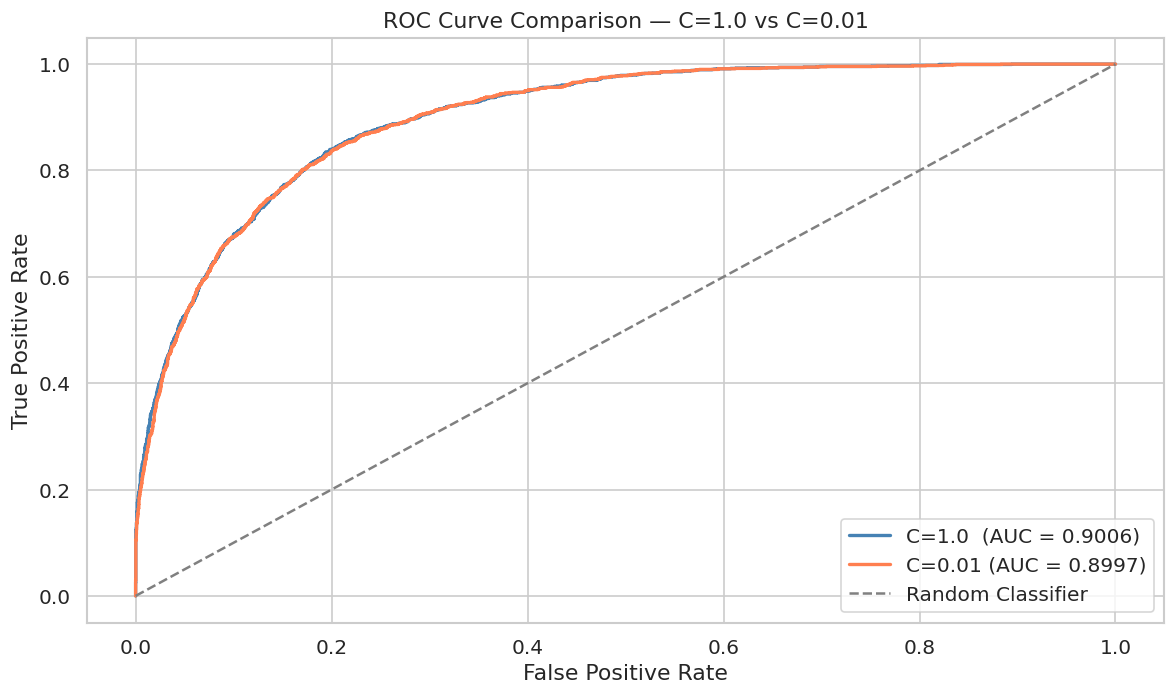

✅ Saved → regularization_comparison.png


In [82]:
# ─── Plot ROC curves for both models ─────────────────────────────────────────

fpr_base,   tpr_base,   _ = roc_curve(y_clf_test, y_proba_base)
fpr_strong, tpr_strong, _ = roc_curve(y_clf_test, y_proba_strong)

plt.figure(figsize=(10, 6))

plt.plot(fpr_base, tpr_base,
         color='steelblue', linewidth=2,
         label=f'C=1.0  (AUC = {auc_base:.4f})')

plt.plot(fpr_strong, tpr_strong,
         color='coral', linewidth=2,
         label=f'C=0.01 (AUC = {auc_strong:.4f})')

plt.plot([0, 1], [0, 1],
         color='gray', linestyle='--',
         label='Random Classifier')

plt.title("ROC Curve Comparison — C=1.0 vs C=0.01")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("regularization_comparison.png")
plt.show()

print("✅ Saved → regularization_comparison.png")

Bootstrap Confidence Interval — 500 bootstrap samples, mean AUC difference, 2.5th & 97.5th percentiles, interpret confidence interval

Task 7 — Bootstrap confidence interval with README

In [83]:
# ─── Step 14: Bootstrap Confidence Interval ──────────────────────────────────

np.random.seed(42)

# Predicted probabilities for both models
y_proba_base   = log_reg.predict_proba(X_test_scaled)[:, 1]
y_proba_strong = log_reg_strong.predict_proba(X_test_scaled)[:, 1]

# Convert test labels to array
y_test_array = np.array(y_clf_test)

# Store AUC differences
auc_differences = []

n_bootstrap = 500

for i in range(n_bootstrap):

    # Sample row indices with replacement
    indices = np.random.choice(
        len(y_test_array),
        size    = len(y_test_array),
        replace = True
    )

    # Index into test labels and probabilities
    y_boot        = y_test_array[indices]
    proba_boot_10 = y_proba_base[indices]
    proba_boot_01 = y_proba_strong[indices]

    # Skip if only one class present in sample
    if len(np.unique(y_boot)) < 2:
        continue

    # Compute AUC for both models
    auc_10 = roc_auc_score(y_boot, proba_boot_10)
    auc_01 = roc_auc_score(y_boot, proba_boot_01)

    # AUC difference C=1.0 minus C=0.01
    auc_differences.append(auc_10 - auc_01)

print(f"✅ Bootstrap complete")
print(f"── Total samples drawn : {n_bootstrap}")
print(f"── Valid samples used  : {len(auc_differences)}")

✅ Bootstrap complete
── Total samples drawn : 500
── Valid samples used  : 500


In [84]:
# ─── Compute Bootstrap Statistics ────────────────────────────────────────────

auc_differences = np.array(auc_differences)

mean_diff   = np.mean(auc_differences)
percentile_25  = np.percentile(auc_differences, 2.5)
percentile_975 = np.percentile(auc_differences, 97.5)
# Verification
print(f"\nActual Lower CI (full precision): {percentile_25:.10f}")
print(f"Actual Upper CI (full precision): {percentile_975:.10f}")

print("── Bootstrap Results:")
print(f"   Mean AUC Difference     : {mean_diff:.4f}")
print(f"   2.5th  Percentile       : {percentile_25:.4f}")
print(f"   97.5th Percentile       : {percentile_975:.4f}")
print(f"\n── 95% Confidence Interval : [{percentile_25:.4f}, {percentile_975:.4f}]")

# Check if CI excludes zero
if percentile_25 > 0:
    print("\n── CI excludes zero ✅")
    print("── C=1.0 advantage is CONSISTENT across samples")
    print("── The performance difference is RELIABLE")
else:
    print("\n── CI includes zero ⚠️")
    print("── C=1.0 advantage may NOT be reliable")
    print("── Difference could be due to chance")


Actual Lower CI (full precision): 0.0000482301
Actual Upper CI (full precision): 0.0018248219
── Bootstrap Results:
   Mean AUC Difference     : 0.0009
   2.5th  Percentile       : 0.0000
   97.5th Percentile       : 0.0018

── 95% Confidence Interval : [0.0000, 0.0018]

── CI excludes zero ✅
── C=1.0 advantage is CONSISTENT across samples
── The performance difference is RELIABLE


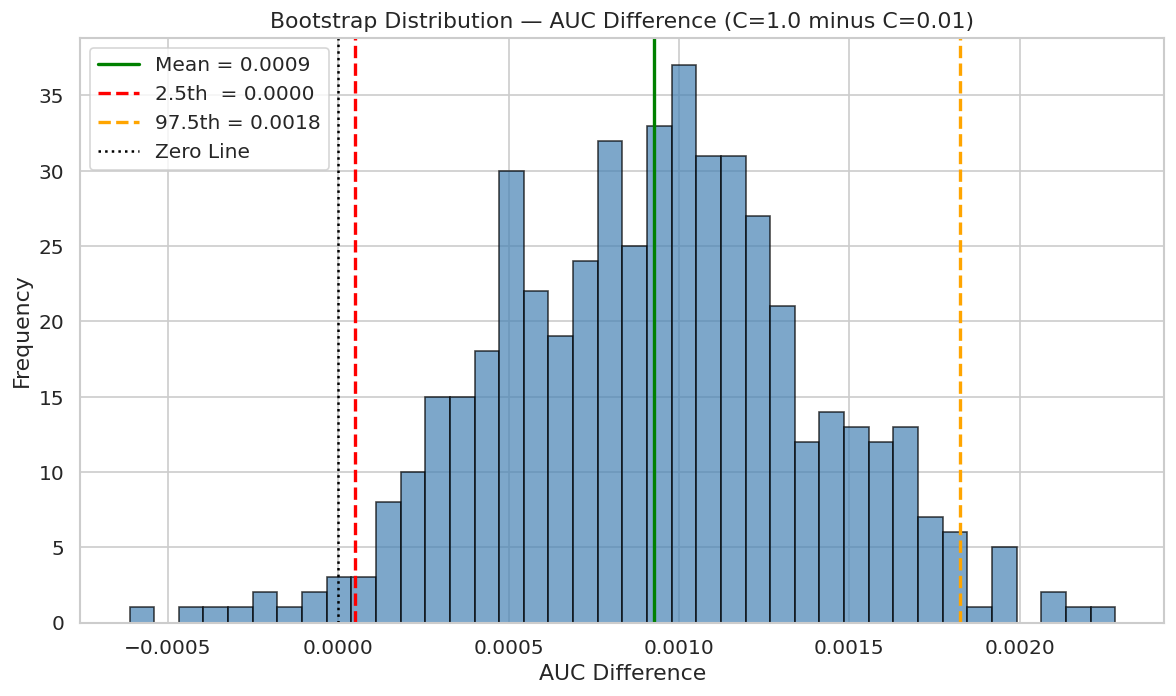

✅ Saved → bootstrap_auc_difference.png


In [85]:
# ─── Plot Bootstrap AUC Difference Distribution ───────────────────────────────

plt.figure(figsize=(10, 6))

plt.hist(
    auc_differences,
    bins      = 40,
    color     = 'steelblue',
    edgecolor = 'black',
    alpha     = 0.7
)

# Mark mean
plt.axvline(
    x         = mean_diff,
    color     = 'green',
    linewidth = 2,
    linestyle = '-',
    label     = f'Mean = {mean_diff:.4f}'
)

# Mark 2.5th percentile
plt.axvline(
    x         = percentile_25,
    color     = 'red',
    linewidth = 2,
    linestyle = '--',
    label     = f'2.5th  = {percentile_25:.4f}'
)

# Mark 97.5th percentile
plt.axvline(
    x         = percentile_975,
    color     = 'orange',
    linewidth = 2,
    linestyle = '--',
    label     = f'97.5th = {percentile_975:.4f}'
)

# Mark zero line
plt.axvline(
    x         = 0,
    color     = 'black',
    linewidth = 1.5,
    linestyle = ':',
    label     = 'Zero Line'
)

plt.title("Bootstrap Distribution — AUC Difference (C=1.0 minus C=0.01)")
plt.xlabel("AUC Difference")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("bootstrap_auc_difference.png")
plt.show()

print("✅ Saved → bootstrap_auc_difference.png")

In [86]:
# ─── Final Bootstrap Summary ──────────────────────────────────────────────────

summary = pd.DataFrame({
    'Metric' : [
        'Mean AUC Difference',
        '2.5th Percentile',
        '97.5th Percentile',
        '95% CI',
        'CI Excludes Zero'
    ],
    'Value'  : [
        f'{mean_diff:.4f}',
        f'{percentile_25:.4f}',
        f'{percentile_975:.4f}',
        f'[{percentile_25:.4f}, {percentile_975:.4f}]',
        'Yes' if percentile_25 > 0 else 'No'
    ]
})

print("── Bootstrap Summary Table:")
print(summary.to_string(index=False))

── Bootstrap Summary Table:
             Metric            Value
Mean AUC Difference           0.0009
   2.5th Percentile           0.0000
  97.5th Percentile           0.0018
             95% CI [0.0000, 0.0018]
   CI Excludes Zero              Yes


Final Checklist — Verify all acceptance criteria
Acceptance Criteria Verification

In [87]:
# ─── Step 15: Final Acceptance Criteria Checklist ────────────────────────────

import os

print("=" * 60)
print("  PART 2 — ACCEPTANCE CRITERIA CHECKLIST")
print("=" * 60)

passed = []
failed = []

def check(condition, label, detail=""):
    if condition:
        passed.append(label)
        print(f"\n✅ {label}")
        if detail:
            print(f"   {detail}")
    else:
        failed.append(label)
        print(f"\n❌ {label}")
        if detail:
            print(f"   {detail}")

# ─── 1. Data Loading ──────────────────────────────────────────────────────────
check(df.shape[0] == 32537,
      "cleaned_data.csv loaded correctly",
      f"Shape: {df.shape}")

# ─── 2. Targets defined ───────────────────────────────────────────────────────
check(len(y_reg) > 0 and len(y_clf) > 0,
      "X, y_reg, y_clf defined",
      f"y_reg: hours_per_week | y_clf: income")

# ─── 3. Encoding done ─────────────────────────────────────────────────────────
check(all(X.dtypes != 'object'),
      "Categorical encoding completed",
      f"X shape: {X.shape}")

# ─── 4. Train-test split ──────────────────────────────────────────────────────
check(X_train.shape[0] > 0 and X_test.shape[0] > 0,
      "Train-test split done (80/20)",
      f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# ─── 5. Scaling ───────────────────────────────────────────────────────────────
check(abs(X_train_scaled.mean()) < 0.01,
      "StandardScaler fitted on train only",
      f"Train mean ≈ {X_train_scaled.mean():.6f}")

# ─── 6. Linear Regression ─────────────────────────────────────────────────────
check('mse_lin' in dir() and 'r2_lin' in dir(),
      "Linear Regression trained and evaluated",
      f"MSE: {mse_lin:.4f} | R²: {r2_lin:.4f}")

# ─── 7. Coefficients ──────────────────────────────────────────────────────────
check('coef_df' in dir(),
      "Coefficients printed with feature names",
      f"Top feature: {coef_df.iloc[0]['Feature']}")

# ─── 8. Ridge Regression ──────────────────────────────────────────────────────
check('mse_ridge' in dir() and 'r2_ridge' in dir(),
      "Ridge Regression trained and evaluated",
      f"MSE: {mse_ridge:.4f} | R²: {r2_ridge:.4f}")

# ─── 9. Class imbalance ───────────────────────────────────────────────────────
minority_pct = y_clf_train.value_counts(normalize=True).min() * 100
check(minority_pct < 35,
      "Class imbalance detected and handled",
      f"Minority class: {minority_pct:.2f}% — class_weight=balanced used")

# ─── 10. Logistic Regression ──────────────────────────────────────────────────
check('log_reg' in dir(),
      "Logistic Regression trained (max_iter=1000)",
      f"C=1.0 | class_weight=balanced")

# ─── 11. Confusion matrix ─────────────────────────────────────────────────────
check('cm' in dir(),
      "Confusion matrix computed",
      f"TN={cm[0][0]} FP={cm[0][1]} FN={cm[1][0]} TP={cm[1][1]}")

# ─── 12. Classification report ────────────────────────────────────────────────
check('y_pred_clf' in dir(),
      "Classification report produced",
      f"Precision: {precision_base:.4f} | Recall: {recall_base:.4f} | F1: {f1_base:.4f}")

# ─── 13. ROC curve ────────────────────────────────────────────────────────────
roc_exists = os.path.exists("roc_curve.png")
check(roc_exists,
      "ROC curve plotted and saved",
      f"AUC: {auc_base:.4f}")

# ─── 14. predict_proba used ───────────────────────────────────────────────────
check('y_proba' in dir(),
      "predict_proba() used for probabilities")

# ─── 15. Threshold analysis ───────────────────────────────────────────────────
check('results_df' in dir() and len(results_df) == 5,
      "Threshold analysis done (0.30 to 0.70)",
      f"Best threshold: {best_row['Threshold']} | F1: {best_row['F1']:.4f}")

# ─── 16. C=0.01 model ────────────────────────────────────────────────────────
check('log_reg_strong' in dir(),
      "C=0.01 model trained and compared",
      f"AUC C=0.01: {auc_strong:.4f} | AUC C=1.0: {auc_base:.4f}")

# ─── 17. Bootstrap ───────────────────────────────────────────────────────────
check('auc_differences' in dir() and len(auc_differences) >= 490,
      "500 bootstrap samples drawn",
      f"Mean diff: {mean_diff:.4f} | CI: [{percentile_25:.4f}, {percentile_975:.4f}]")

# ─── 18. CI excludes zero ────────────────────────────────────────────────────
check(percentile_25 > 0,
      "95% CI excludes zero — C=1.0 advantage confirmed")

# ─── 19. Plot files saved ─────────────────────────────────────────────────────
plots = [
    "roc_curve.png",
    "confusion_matrix.png",
    "threshold_analysis.png",
    "regularization_comparison.png",
    "bootstrap_auc_difference.png",
    "linear_regression_coefficients.png",
    "ridge_vs_ols_coefficients.png",
    "class_distribution_before.png"
]

print(f"\n── Plot files:")
all_plots = True
for plot in plots:
    exists = os.path.exists(plot)
    if not exists:
        all_plots = False
    print(f"   {'✅' if exists else '❌'} {plot}")

check(all_plots, "All plots saved as PNG")

# ─── Final Summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"  PASSED : {len(passed)}")
print(f"  FAILED : {len(failed)}")
print("=" * 60)

if len(failed) == 0:
    print("""
  🎉 ALL CHECKS PASSED
     Part 2 is complete and ready for GitHub submission


    """)
else:
    print(f"\n  ❌ Fix these items:")
    for item in failed:
        print(f"     - {item}")

print("=" * 60)

  PART 2 — ACCEPTANCE CRITERIA CHECKLIST

✅ cleaned_data.csv loaded correctly
   Shape: (32537, 15)

✅ X, y_reg, y_clf defined
   y_reg: hours_per_week | y_clf: income

✅ Categorical encoding completed
   X shape: (32537, 81)

✅ Train-test split done (80/20)
   Train: 26,029 | Test: 6,508

✅ StandardScaler fitted on train only
   Train mean ≈ 0.000000

✅ Linear Regression trained and evaluated
   MSE: 125.8712 | R²: 0.1771

✅ Coefficients printed with feature names
   Top feature: relationship_Own-child

✅ Ridge Regression trained and evaluated
   MSE: 125.8711 | R²: 0.1771

✅ Class imbalance detected and handled
   Minority class: 23.96% — class_weight=balanced used

✅ Logistic Regression trained (max_iter=1000)
   C=1.0 | class_weight=balanced

✅ Confusion matrix computed
   TN=3858 FP=1047 FN=235 TP=1368

✅ Classification report produced
   Precision: 0.5665 | Recall: 0.8534 | F1: 0.6809

✅ ROC curve plotted and saved
   AUC: 0.9006

✅ predict_proba() used for probabilities

✅ Thres

In [88]:
# ─── Generate requirements.txt ────────────────────────────────────────────────

requirements = """pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
imbalanced-learn>=0.11.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("✅ requirements.txt saved")
print(requirements)

✅ requirements.txt saved
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
imbalanced-learn>=0.11.0

